## Qubit + cavidad en el THz
Sea un qubit acoplado a dos cavidades:
1. Una de ellas con frecuencia en el óptico. Acoplo muy débil que permite hallar su espectro de emisión
2. Otra con frecuencia en el régimen THz

El objetivo es estudiar el efecto del acoplo entre el qubit y THz en el espectro de emisión.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from scipy.signal import find_peaks

Parámetros físicos

In [4]:
Omega = 20   # drive del qubit

gamma = 1       #decay en el qubit
kappa_a = 1     #decay en la cavidad del sensor
kappa_b = 1     #decay en la cav de THz

g = 0.001       # acoplo qubit con optico
chi =  1      # acoplo qubit con THz

Na = 2        # truncación de la primera cavidad 
Nb = 3         # segunda cavidad



Operadores

In [5]:
# Operadores en el espacio producto tensorial
sx = tensor( sigmax(), qeye(Na), qeye(Nb))
sp = tensor( sigmap(), qeye(Na), qeye(Nb))
sm = tensor( sigmam(), qeye(Na), qeye(Nb))
sz = tensor( sigmaz(), qeye(Na), qeye(Nb))

a = tensor( qeye(2), destroy(Na) , qeye(Nb))
a_plus = a.dag()

b = tensor( qeye(2), qeye(Na), destroy(Nb))
b_plus = b.dag()

# Disipadores
Dissipators = []

Dissipators.append(np.sqrt(gamma) * sm)
Dissipators.append(np.sqrt(kappa_a) * a)
Dissipators.append(np.sqrt(kappa_b) * b)

Preparamos el barrido en valores de $\Delta$

In [6]:
npoints = 80

# valores a probar de w_THz
w_THz_list = np.linspace(10,35,9)

# eje horizontal (frecuencia espectral)
Delta_a_list = np.linspace(-3*Omega, 3*Omega, npoints)

# eje vertical (detuning del qubit)
Delta_q_list = np.linspace(-3*Omega, 3*Omega, npoints)



Hamiltoniano: $$H = \frac{\Omega}{2}\sigma_x + \omega_{THz}b^\dagger b+ \Delta_a a^\dagger a +\Delta_q\sigma_z + g(a^\dagger\sigma_- + a\sigma_+) + \chi(\sigma_z+1)(a + a^\dagger)$$

Cuando la cavidad está muy debilmente acoplada, podemos calcular el espectro como $$S(\omega)\ \alpha\ \braket{a^\dagger a}^{SS}$$.


Donde $$\braket{a^\dagger a}^{SS} = Tr(\rho_{SS}a^\dagger a)$$

Calcular $S(\omega)$  y $\log S(\omega)$ con $\Delta_q$ y $\Delta_a$.

In [47]:
# Diccionario para guardar todos los mapas por valor de w_b
all_S_maps = {}

# Doble bucle
for idx, w_b in enumerate(w_THz_list):

    S_map = np.zeros((len(Delta_q_list), len(Delta_a_list)))

    for i, Delta_q in enumerate(Delta_q_list):
        
        for j, Delta_a in enumerate(Delta_a_list):
            
        # Hamiltoniano
            H = (Omega/2) * sx \
            + Delta_a * a_plus * a + Delta_q * sz \
            + w_b * b_plus * b \
            + g * (a_plus * sm + a * sp) + chi * (sz+ 1)*(b_plus + b)

            rho_SS = steadystate(H, Dissipators)
            
            S_map[i, j] = expect(a_plus*a, rho_SS)

    # Guardar el mapa
    all_S_maps[w_b] = S_map



KeyboardInterrupt: 

### Gráficas de los mapas
Con líneas verticales que marcan el valor de $\omega_{THz}$ y líneas horizontales con el $Delta_q$ que hemos calculado

NameError: name 'all_S_maps' is not defined

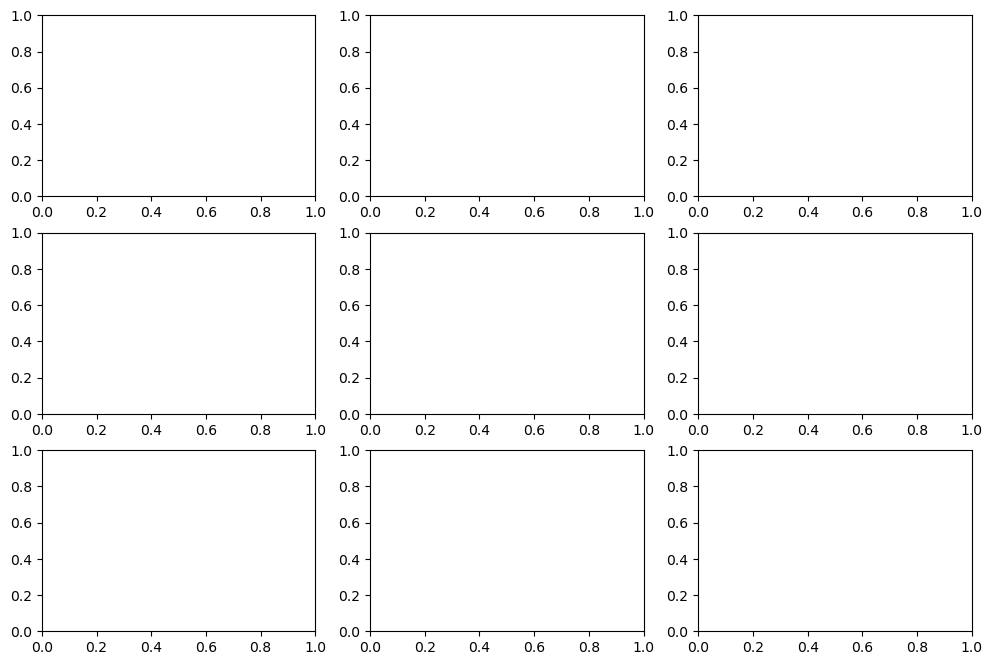

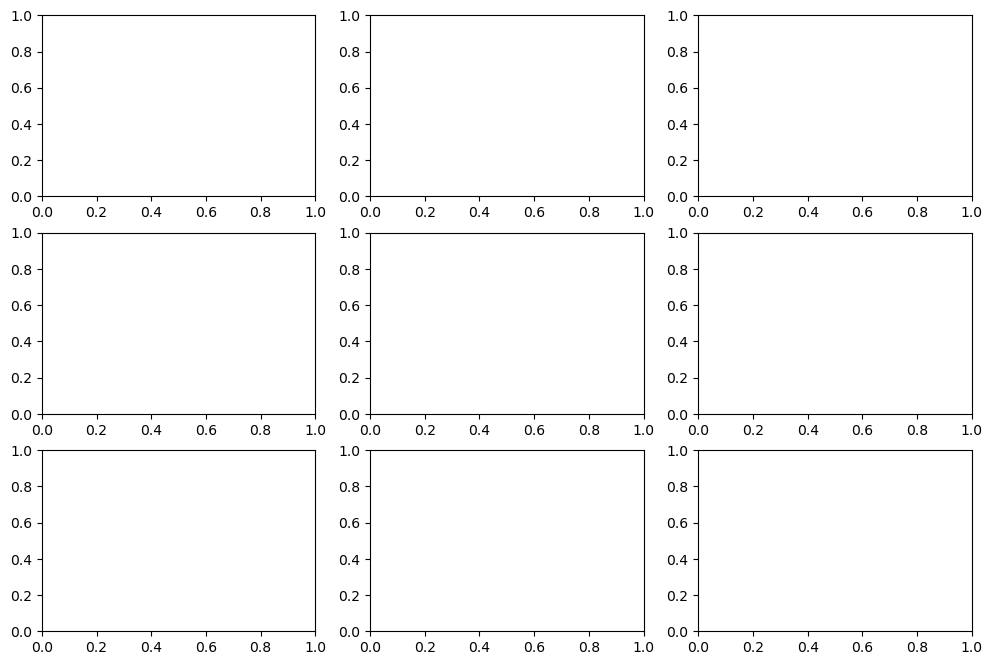

In [20]:
# Crear figuras y ejes
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

fig_log, axes_log = plt.subplots(3, 3, figsize=(12, 8))
axes_log = axes_log.flatten()

for idx, w_b in enumerate(w_THz_list):

    Delta_q = 0
    if w_b > Omega:
        Delta_q = 1/2*np.sqrt(w_b**2 - Omega**2)

    S_map = all_S_maps[w_b]   # Recuperar mapa ya calculado
    ax = axes[idx]
    ax_log = axes_log[idx]

    # ------------------------
    # Mapa normal
    # ------------------------
    im = ax.imshow(
        S_map,
        extent=[Delta_a_list[0], Delta_a_list[-1],
                Delta_q_list[0], Delta_q_list[-1]],
        aspect='auto',
        origin='lower'
    )

    ax.axvline(x=-w_b, linestyle='--', color='white', linewidth=1.5)
    ax.axhline(y=-Delta_q, linestyle='--', color='red', linewidth=1.5)
    ax.set_xlabel("Detuning cavidad $\\Delta_a/\\gamma$")
    ax.set_ylabel("Detuning qubit $\\Delta_q/\\gamma$")
    ax.set_title(rf"$\omega_b = {w_b:.2f}\gamma$")
    ax.set_ylim(-20, 20)
    fig.colorbar(im, ax=ax, label=r"$S\ \langle a^\dagger a \rangle_{ss}$")

    # --------------------------
    # Mapa logarítmico
    # --------------------------
    S_log = np.log10(S_map + 1e-12)
    im_log = ax_log.imshow(
        S_log,
        extent=[Delta_a_list[0], Delta_a_list[-1],
                Delta_q_list[0], Delta_q_list[-1]],
        aspect='auto',
        origin='lower'
    )

    ax_log.axvline(x=-w_b, linestyle='--', color='white', linewidth=1.5)
    ax_log.axhline(y=-Delta_q, linestyle='--', color='red', linewidth=1.5)
    ax_log.set_xlabel("Detuning cavidad $\\Delta_a/\\gamma$")
    ax_log.set_ylabel("Detuning qubit $\\Delta_q/\\gamma$")
    ax_log.set_title(rf"$\omega_b = {w_b:.2f}\gamma$ (log10)")
    ax_log.set_ylim(-20, 20)
    fig_log.colorbar(im_log, ax=ax_log, label=r"$\log_{10}(S)$")

plt.tight_layout()
fig.tight_layout()
fig_log.tight_layout()
plt.show()

A continuación, creamos gráficos de $S(\omega)$ en el que el valor de $\Delta_q$ es aquel que corresponde al pico nuevo.
Esto ocurre cuando $\omega_{THz} = \Omega_R$, donde $\Omega_R = 2\sqrt{\Delta_q ^2 + \frac{\Omega}{2} }$. Es decir, veremos el pico cuando $\Delta_q = \sqrt{ \frac{\omega_{THz}^2}{4}-\frac{\Omega^2}{4}}$, para lo que debe cumplirse $\omega_{THz} > \Omega$.

Pasos:

1. Bucle que itera en valores de $\omega_b$. Hay 2 términos del  Hamiltoniano que dependen de $\omega_b$ : $$w_b b^\dagger b, \ \Delta_q(\omega_b)\sigma_z$$

2. Bucle que itera en $\Delta_a$ para poder calcular el espectro como $$S\ \alpha\ \braket{a^\dagger a} = Tr(\rho_{ss} a^\dagger a)$$


Y a parte, también haremos el mismo cálculo pero sin acoplar la cavidad THz, para comparar los gráficos.


ValueError: Matrix is singular

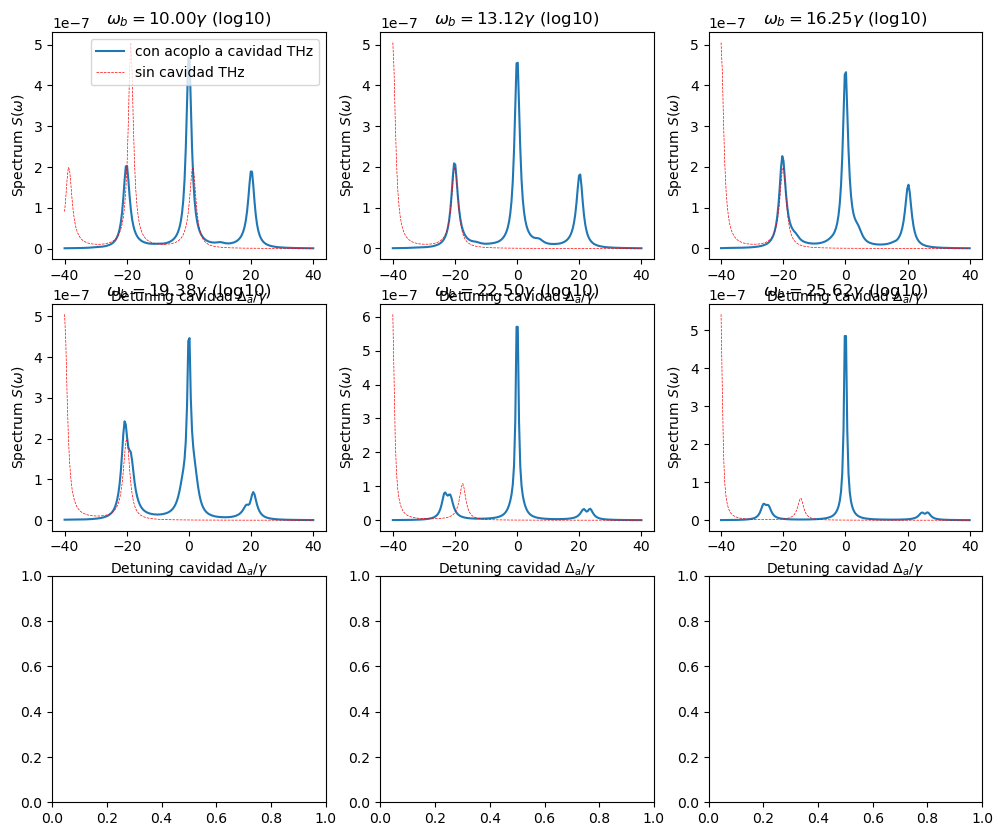

In [ ]:
fig_peaks, axes_peaks = plt.subplots(3,3, figsize=(12,10))
axes_peaks = axes_peaks.flatten()

# Primero: definir los disipadores en el caso sin cavidad THz
Dissipators_without = []

Dissipators_without.append(np.sqrt(gamma) * sm)
Dissipators_without.append(np.sqrt(kappa_a) * a) # al no acoplar la cavidad THz, no consideramos la disipación en ella
# 🔧 fix
Dissipators_without.append(np.sqrt(1e-6) * a)

# sumentamos el numero de puntos en Delta_a
Delta_a_list = np.linspace(-2*Omega, 2*Omega, 200)

# Encontrar los picos y almacenarlos
ratios_all = []
peaks_all_with = []
peaks_all_without = []

for idx, w_b in enumerate(w_THz_list):

    Delta_q = 0

    spectrum=[]
    spectrum_without = []

    ax = axes_peaks[idx]
    
    if w_b > Omega:
        Delta_q = 1/2*np.sqrt(w_b**2 - Omega**2)

    # hamiltoniano para el caso con acoplo a THz (faltarían los términos con Delta_a)
    H0 =  (Omega/2) * sx \
            + w_b * b_plus * b \
            + g * (a_plus * sm + a * sp) + chi * (sz+ 1)*(b_plus + b) + Delta_q * sz
    
    # hamiltoniano para el caso sin acoplo a THz
    H0_without = (Omega/2) * sx \
            + g * (a_plus * sm + a * sp) + Delta_q * sz 
    
    for j, Delta_a in enumerate(Delta_a_list):

        # hamiltonianos totales
        H = H0 + Delta_a * a_plus*a 
        H_without = H0_without + Delta_a * a_plus*a

        # matriz densidad en el estado estacionario
        rho_SS = steadystate(H, Dissipators)
        rho_SS_without = steadystate(H_without, Dissipators_without)

        # población en el estado estacionario y espectros
        pop_SS = expect(a_plus * a, rho_SS)
        pop_SS_without = expect(a_plus * a, rho_SS_without)

        spectrum.append(pop_SS)
        spectrum_without.append(pop_SS_without)
    
    spectrum = np.array(spectrum)
    spectrum_without = np.array(spectrum_without)

    # detectar picos
    peaks_idx_1, _ = find_peaks(spectrum)
    peaks_idx_2, _ = find_peaks(spectrum_without)

    #seleccionar los 3 más altos 
    top3_1 = peaks_idx_1[np.argsort(spectrum[peaks_idx_1])[-3:]]
    top3_2 = peaks_idx_2[np.argsort(spectrum_without[peaks_idx_2])[-3:]]

    # ordenar por posición en Delta_a
    top3_1 = np.sort(top3_1)
    top3_2 = np.sort(top3_2)
    peaks1 = spectrum[top3_1]
    peaks2 = spectrum_without[top3_2]

  
    peaks_all_with.append(peaks1)
    peaks_all_without.append(peaks2)

    ratio = peaks1 / peaks2
    ratios_all.append(ratio)

    ax.plot(Delta_a_list, spectrum, label='con acoplo a cavidad THz')
    ax.plot(Delta_a_list, spectrum_without, '--', color = 'red', linewidth = 0.5,  label = 'sin cavidad THz')

    if idx == 0:
        ax.legend()

    ax.set_title(rf"$\omega_b = {w_b:.2f}\gamma$ (log10)")
    ax.set_xlabel("Detuning cavidad $\\Delta_a/\\gamma$")
    ax.set_ylabel("Spectrum $S(\omega)$")
fig_peaks.tight_layout()

# Convertir a array (forma: N_wb x 3)
ratios_all = np.array(ratios_all)

# Separar los tres picos
ratios_left = ratios_all[:, 0]
ratios_center = ratios_all[:, 1]
ratios_right = ratios_all[:, 2]

# Plot
plt.figure(figsize=(7,5))

plt.plot(w_THz_list, ratios_left, 'o-', label='Left')
plt.plot(w_THz_list, ratios_center, 'o-', label='Central')
plt.plot(w_THz_list, ratios_right, 'o-', label='Right')

plt.xlabel(r"$\omega_b$")
plt.ylabel("Ratio (with coupling / without)")
plt.title("Peaks ratio$")

plt.legend()
plt.show()

Again, peaks ratios but this time, we only compute $S(\omega)$ at the position of the peaks (which is known)  and for a continuum in $\omega_{THz}$
Peaks at: $\Delta_a = {0, \pm\Omega_R}$, where $\Omega_R = 2\sqrt{\Delta_q ^2 + \frac{\Omega}{2} } = \omega_{THz} $ (bc we choose \Delta_q so that this is true)$

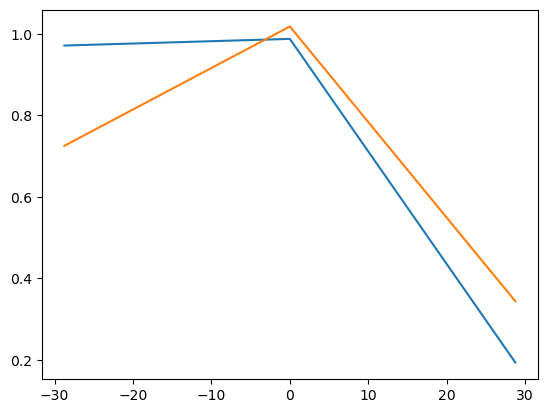

In [15]:
w_THz_list = [20,28.75]

peaks_with = np.zeros((3,len(w_THz_list)))
peaks_without = np.zeros((3,len(w_THz_list)))
ratio_peaks = np.zeros((3,len(w_THz_list)))
                   
# Primero: definir los disipadores en el caso sin cavidad THz
Dissipators_without = []

Dissipators_without.append(np.sqrt(gamma) * sm)
Dissipators_without.append(np.sqrt(kappa_a) * a) # al no acoplar la cavidad THz, no consideramos la disipación en ella


for idx, w_b in enumerate(w_THz_list):

    Delta_a_list = [-w_b,0,w_b]
    Delta_q = 0
    
    if w_b > Omega:
        Delta_q = 1/2*np.sqrt(w_b**2 - Omega**2)

    # hamiltoniano para el caso con acoplo a THz (faltarían los términos con Delta_a)
    H0 =  (Omega/2) * sx \
            + w_b * b_plus * b \
            + g * (a_plus * sm + a * sp) + chi * (sz+ 1)*(b_plus + b) + Delta_q * sz
    
    # hamiltoniano para el caso sin acoplo a THz
    H0_without = (Omega/2) * sx \
            + g * (a_plus * sm + a * sp) + Delta_q * sz
    
    for idx2, Delta_a in enumerate(Delta_a_list):

        # hamiltonianos totales
        H = H0 + Delta_a * a_plus*a 
        H_without = H0_without + Delta_a * a_plus*a

        # matriz densidad en el estado estacionario
        rho_SS = steadystate(H, Dissipators)
        rho_SS_without = steadystate(H_without, Dissipators)

        # población en el estado estacionario y espectros
        peaks_with[idx2,idx]= expect(a_plus * a, rho_SS)
        peaks_without[idx2,idx] = expect(a_plus * a, rho_SS_without)
        ratio_peaks[idx2, idx] = peaks_with[idx2, idx] / peaks_without[idx2, idx]

plt.plot(Delta_a_list, ratio_peaks)